In [1]:
%matplotlib ipympl

import csv
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import pandas as pd
import netCDF4 as nc
import glob
import tqdm

# Contrails colormap
from matplotlib.colors import ListedColormap
colors1 = plt.cm.Greys_r(np.linspace(0.2, 0.8, 213))
colors2 = plt.cm.Blues(np.linspace(0.2, 0.6, 42))
colors = np.vstack((colors1, colors2))
cmap = ListedColormap(colors)

## Load Datasets

In [3]:
# Load GRUAN data
years = ['2005','2006','2007','2008','2009','2010','2011','2012','2013','2014','2015','2016','2017','2018','2019','2020','2021'] # Years of interest

# Get all GRUAN radiosonde files
files = []
for year in years:
    files.extend(glob.glob('/home/chinahg/GCresearch/GRUAN_sondes/ftp.ncdc.noaa.gov/pub/data/gruan/processing/level2/RS92-GDP/version-002/'+'/**/'+year+'/*.nc', recursive=True))
files.sort()
num_files = len(files)

# Initialize lists to store data
rh_list = []
rh_i_list = []
alt_list = []
lat_list = []
lon_list = []
datetime_list = []

# Loop through each file and extract the data
for i in tqdm.tqdm(range(num_files), desc="Processing GRUAN files"):
    path2file = files[i]
    nc_GRUAN = nc.Dataset(path2file, 'r', format='NETCDF4_CLASSIC')
    GRUAN_RHw = nc_GRUAN.variables['rh'][:]  # [unitless, not %]
    GRUAN_RHi = nc_GRUAN.variables['rh_i'][:]  # [unitless, not %]
    altitude = nc_GRUAN.variables['alt'][:]  # Assuming 'alt' is the variable for altitude
    latitude = nc_GRUAN.variables['lat'][:]
    longitude = nc_GRUAN.variables['lon'][:]
    datetime = nc_GRUAN.variables['time'][:]

    # Append data to lists
    rh_list.extend(GRUAN_RHw)
    rh_i_list.extend(GRUAN_RHi)
    alt_list.extend(altitude)
    lat_list.extend(latitude)
    lon_list.extend(longitude)
    datetime_list.extend(datetime)

    nc_GRUAN.close()

# Create a DataFrame
df_GRUAN = pd.DataFrame({
    'RH': rh_list,
    'RH_i': rh_i_list,
    'Altitude': alt_list,
    'Latitude': lat_list,
    'Longitude': lon_list,
    'Datetime': datetime_list
})

# for i in range(num_files):
#     path2file = files[i]
#     nc_GRUAN = nc.Dataset(path2file, 'r', format='NETCDF4_CLASSIC')
#     GRUAN_RHw = nc_GRUAN.variables['rh'][:] # [unitless, not %]
#     GRUAN_RHi = nc_GRUAN.variables['rh_i'][:] # [unitless, not %]
    
#     altitude = nc_GRUAN.variables['alt'][:]  # Assuming 'alt' is the variable for altitude

#     nc_GRUAN.close()


Processing GRUAN files:   6%|▌         | 1508/24198 [01:29<22:22, 16.90it/s]


KeyboardInterrupt: 

In [4]:
from mpl_toolkits.mplot3d import Axes3D 

# Initialize lists to store the accumulated data
all_filtered_altitude = []
all_filtered_RHi = []

# Loop through each file and extract the data
for path2file in tqdm.tqdm(files, desc="Processing GRUAN files"):
    nc_GRUAN = nc.Dataset(path2file, 'r', format='NETCDF4_CLASSIC')
    GRUAN_RHi = nc_GRUAN.variables['rh_i'][:]  # [unitless, not %]
    altitude = nc_GRUAN.variables['alt'][:]  # Assuming 'alt' is the variable for altitude

    # Filter the data for altitudes between 1000m and 15000m
    altitude_mask = (altitude >= 1000) & (altitude <= 15000)
    filtered_altitude = altitude[altitude_mask]
    filtered_RHi = GRUAN_RHi[altitude_mask]

    # Remove NaN values
    valid_mask = ~np.isnan(filtered_altitude) & ~np.isnan(filtered_RHi)
    filtered_altitude = filtered_altitude[valid_mask]
    filtered_RHi = filtered_RHi[valid_mask]

    # Append the filtered data to the lists
    all_filtered_altitude.extend(filtered_altitude)
    all_filtered_RHi.extend(filtered_RHi)

    # Close the NetCDF file
    nc_GRUAN.close()


Processing GRUAN files: 100%|██████████| 24198/24198 [06:53<00:00, 58.55it/s]


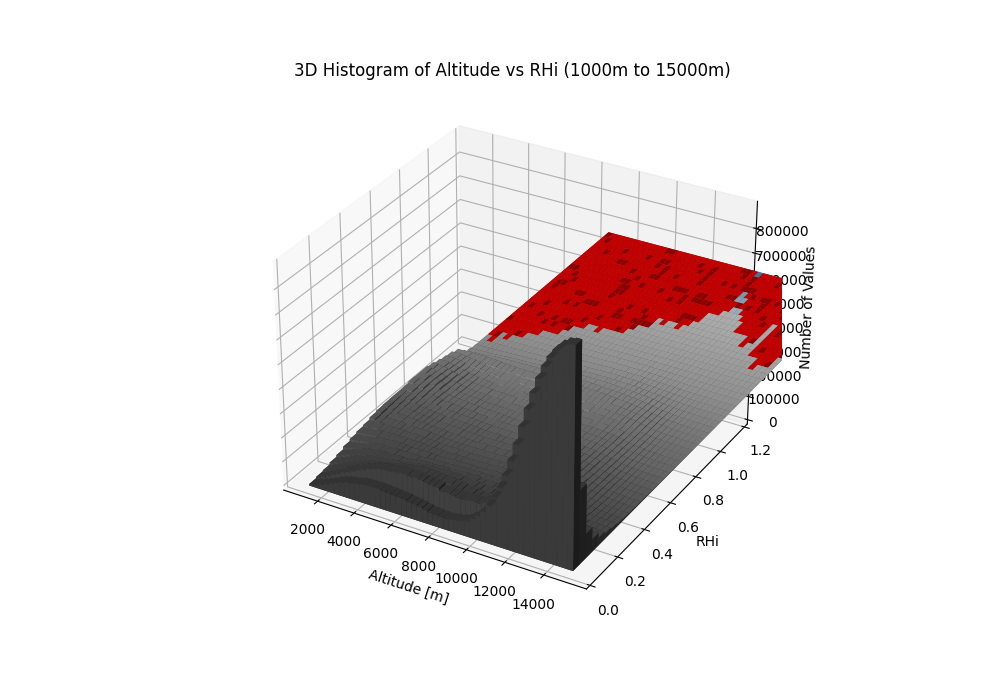

In [4]:
dpi = 300
# Convert lists to numpy arrays
all_filtered_altitude = np.array(all_filtered_altitude)
all_filtered_RHi = np.array(all_filtered_RHi)

# Define the number of bins for altitude and RHi
num_bins_altitude = 50
num_bins_RHi = 50

# Create the histogram
hist, edges = np.histogramdd((all_filtered_altitude, all_filtered_RHi), bins=(num_bins_altitude, num_bins_RHi))

# Get the bin centers
altitude_centers = (edges[0][:-1] + edges[0][1:]) / 2
RHi_centers = (edges[1][:-1] + edges[1][1:]) / 2

# Create a meshgrid for plotting
altitude_mesh, RHi_mesh = np.meshgrid(altitude_centers, RHi_centers, indexing="ij")

# Plot the 3D histogram
fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection='3d')

# Use bar3d to create the 3D histogram
xpos, ypos = np.meshgrid(altitude_centers, RHi_centers, indexing="ij")
xpos = xpos.ravel()
ypos = ypos.ravel()
zpos = np.zeros_like(xpos)
dx = (edges[0][1] - edges[0][0]) * np.ones_like(zpos)
dy = (edges[1][1] - edges[1][0]) * np.ones_like(zpos)
dz = hist.ravel()

# Normalize the colors based on the RHi values
norm = plt.Normalize(vmin=all_filtered_RHi.min(), vmax=all_filtered_RHi.max())
colors = cmap(norm(ypos))

# Set the color for cells with no data to red
colors[dz == 0] = [1, 0, 0, 1]  # RGBA for red

chart = ax.bar3d(xpos, ypos, zpos, dx, dy, dz, color=colors, zsort='average')
ax.set_xlabel('Altitude [m]')
ax.set_ylabel('RHi')
ax.set_zlabel('Number of Values')
ax.set_title('3D Histogram of Altitude vs RHi (1000m to 15000m)')
ax.set_ylim(0, 1.2)  # Set the RHi axis limits from 0 to 1.5
plt.show()

In [ ]:
plt.close()
from matplotlib.colors import LogNorm

plt.rcParams['figure.dpi'] = 200

fig, ax = plt.subplots()

# Plot the colormap with log scale
c = ax.pcolormesh(RHi_centers, altitude_centers, hist, norm=LogNorm())

# Add color bar
cb = fig.colorbar(c, ax=ax)
cb.set_label('Density (log scale)')

# Add vertical black dashed line at RHi = 100
ax.axvline(x=1.0, color='black', linestyle='--')

# Set labels and title
ax.set_xlabel('RHi')
ax.set_ylabel('Altitude [m]')
ax.set_title('Colormap of Altitude vs RHi Density (Log Scale)')

plt.show()


In [ ]:
# Find the indices where RHi_centers are greater than or equal to 100
indices = np.where(RHi_centers >= 1.0)[0]

# Sum the histogram values for these indices
sum_hist_values = hist[:, indices].sum()

print("Sum of histogram values for RHi >= 100%:", sum_hist_values)

In [ ]:
# Define the altitude range
altitude_min = 9000
altitude_max = 13000

# Apply the mask to filter the altitudes within the specified range
altitude_mask = (all_filtered_altitude >= altitude_min) & (all_filtered_altitude <= altitude_max)

# Apply the mask to filter RHi values greater than or equal to 1
RHi_mask = all_filtered_RHi >= 1.0

# Combine both masks
combined_mask = altitude_mask & RHi_mask

# Count the number of datapoints within the specified range and RHi >= 1
num_datapoints = np.sum(combined_mask)

print(f"Number of datapoints within the altitude range of {altitude_min} and {altitude_max} and RHi >= 1: {num_datapoints}")

In [ ]:
total_datapoints = len(rh_list) + len(rh_i_list) + len(alt_list)
print(f"Total number of datapoints: {total_datapoints}")

In [ ]:
# Define the altitude range
altitude_min = 9000
altitude_max = 13000

# Apply the mask to filter the altitudes within the specified range
altitude_mask = (all_filtered_altitude >= altitude_min) & (all_filtered_altitude <= altitude_max)

# Filter the RHi values based on the altitude mask
filtered_RHi = all_filtered_RHi[altitude_mask]

# Plot the histogram with KDE
plt.figure()
sns.histplot(filtered_RHi, bins=50, color='blue', edgecolor='black', kde=True, alpha=0.7)
plt.xlabel('RHi')
plt.ylabel('Frequency')
plt.title('Histogram of RHi values between 9000m and 13000m')
plt.grid(False)  # Remove gridlines
plt.show()

In [ ]:
# Define the number of bins for RHi
num_bins_RHi = 50

# Initialize a dictionary to store the histogram counts for each site
site_histograms = {site: np.zeros(num_bins_RHi) for site in unique_sites}

# Define the bin edges for RHi
bin_edges = np.linspace(all_filtered_RHi.min(), all_filtered_RHi.max(), num_bins_RHi + 1)

# Loop through each file and accumulate the histogram counts for each site
for path2file in tqdm.tqdm(files, desc="Processing GRUAN files"):
    nc_GRUAN = nc.Dataset(path2file, 'r', format='NETCDF4_CLASSIC')
    GRUAN_RHi = nc_GRUAN.variables['rh_i'][:]  # [unitless, not %]
    altitude = nc_GRUAN.variables['alt'][:]  # Assuming 'alt' is the variable for altitude

    # Filter the data for altitudes between 1000m and 15000m
    altitude_mask = (altitude >= 1000) & (altitude <= 15000)
    filtered_RHi = GRUAN_RHi[altitude_mask]

    # Remove NaN values
    valid_mask = ~np.isnan(filtered_RHi)
    filtered_RHi = filtered_RHi[valid_mask]

    # Get the site code from the file path
    site_code = path2file.split('/')[-3]
    
    # Accumulate the histogram counts for the site
    site_histograms[site_code] += np.histogram(filtered_RHi, bins=bin_edges)[0]

    # Close the NetCDF file
    nc_GRUAN.close()

In [ ]:
# Calculate the total histogram counts
total_histogram = np.sum(list(site_histograms.values()), axis=0)

# Calculate the relative frequency
relative_frequency = total_histogram / np.sum(total_histogram)

# Plot the relative frequency
plt.figure()
bottom = np.zeros(num_bins_RHi)

for site, hist in site_histograms.items():
    relative_hist = hist / np.sum(hist)
    plt.bar(bin_edges[:-1], relative_hist, width=np.diff(bin_edges), bottom=bottom, label=site, color=site_color_map[site])
    bottom += relative_hist

plt.xlabel('RHi')
plt.ylabel('Relative Frequency')
plt.title('Relative Frequency of RHi values segmented by site code')
plt.legend(loc='upper right')
plt.show()

## ERA5 Data Processing

In [11]:
import os
from scipy.spatial import cKDTree
from datetime import datetime, timedelta

# Function to load ERA5 data
def load_era5_data(files):
    era5_data = []
    for file in files:
        nc_era5 = nc.Dataset(file, 'r', format='NETCDF4_CLASSIC')
        lat = nc_era5.variables['latitude'][:]
        lon = nc_era5.variables['longitude'][:]
        alt = nc_era5.variables['altitude'][:]  # Assuming 'altitude' is the variable for altitude
        time = nc_era5.variables['time'][:]
        rh_w = nc_era5.variables['rh_w'][:]  # Assuming 'rh_w' is the variable for RH_w
        rh_i = nc_era5.variables['rh_i'][:]  # Assuming 'rh_i' is the variable for RH_i
        era5_data.append((lat, lon, alt, time, rh_w, rh_i))
        nc_era5.close()
    return era5_data

# Load ERA5 data files
era5_files = glob.glob('/home/chinahg/GCresearch/contrailuncertainty/ERA5_processing/ERA5_downloads/ERA5_downloads/**/*.nc', recursive=True)
era5_data = load_era5_data(era5_files)

# Create a KDTree for fast nearest neighbor search
lat_lon_alt = []
for lat, lon, alt, time, rh_w, rh_i in era5_data:
    for i in range(len(lat)):
        for j in range(len(lon)):
            for k in range(len(alt)):
                lat_lon_alt.append((lat[i], lon[j], alt[k]))

tree = cKDTree(lat_lon_alt)

# Function to find the nearest ERA5 data point
def find_nearest_era5(lat, lon, alt, time):
    dist, idx = tree.query((lat, lon, alt))
    nearest_lat, nearest_lon, nearest_alt = lat_lon_alt[idx]
    nearest_time = min(era5_data, key=lambda x: abs(x[3] - time))[3]
    nearest_rh_w = era5_data[idx][4]
    nearest_rh_i = era5_data[idx][5]
    return nearest_lat, nearest_lon, nearest_alt, nearest_time, nearest_rh_w, nearest_rh_i

# Create a new DataFrame to store the matched data
matched_data = {
    'Latitude': [],
    'Longitude': [],
    'Altitude': [],
    'Datetime': [],
    'RH_w': [],
    'RH_i': []
}

# Iterate through df_GRUAN and find the nearest ERA5 data point
for index, row in df_GRUAN.dropna(subset=['Latitude', 'Longitude', 'Altitude']).iterrows():
    lat, lon, alt, time = row['Latitude'], row['Longitude'], row['Altitude'], row['Datetime']
    nearest_lat, nearest_lon, nearest_alt, nearest_time, nearest_rh_w, nearest_rh_i = find_nearest_era5(lat, lon, alt, time)
    matched_data['Latitude'].append(nearest_lat)
    matched_data['Longitude'].append(nearest_lon)
    matched_data['Altitude'].append(nearest_alt)
    matched_data['Datetime'].append(nearest_time)
    matched_data['RH_w'].append(nearest_rh_w)
    matched_data['RH_i'].append(nearest_rh_i)

df_matched = pd.DataFrame(matched_data)
print(df_matched.head())

In [2]:
df_matched

NameError: name 'df_matched' is not defined

# Plot GRUAN Meteorological Data

In [ ]:
plt.rcParams['figure.dpi'] = 300

fig, ax = plt.subplots()
hb = ax.hexbin(x = GRUAN_RH, y = GRUAN_MLD, gridsize = 70, cmap = 'Reds', mincnt=1, bins='log')
ax.set_title("GRUAN Supersaturation and Moist Layer Depth, 2005-2021")
plt.xlabel("Cruise RH wrt ice [%]")
plt.ylabel("Moist Layer Depth [m]")
cb = fig.colorbar(hb, ax=ax, label='Counts')
plt.show()

# Plot ERA5 Meteorological Data

In [ ]:
plt.rcParams['figure.dpi'] = 300

fig, ax = plt.subplots()
hb = ax.hexbin(x = ERA5_RH, y = ERA5_MLD, gridsize = 70, cmap = 'Blues', mincnt=1, bins='log', alpha=0.4)
ax.set_title("ERA5 Supersaturation and Moist Layer Depth, 2005-2021")
plt.xlabel("Cruise RH wrt ice [%]")
plt.ylabel("Moist Layer Depth [m]")
plt.ylim(0, 5000)
cb = fig.colorbar(hb, ax=ax, label='Counts')
plt.show()

# Plot ERA5 vs GRUAN Meteorological Data

In [ ]:
# Clean out 0 values

In [ ]:
plt.rcParams['figure.dpi'] = 300

fig, ax1  = plt.subplots()
ax2 = ax1.twinx()
hb1 = ax1.hexbin(x = ERA5_RH, y = ERA5_MLD, gridsize = 70, cmap = 'Blues', mincnt=1, bins='log', 
                 label='ERA5', alpha=0.4)
hb2 = ax2.hexbin(x = GRUAN_RH, y = GRUAN_MLD, gridsize = 70, cmap = 'Reds', mincnt=1, bins='log', 
                 label='GRUAN', alpha=0.4)
ax1.set_title("Supersaturation and Moist Layer Depth")
ax1.set_xlabel("Cruise RH wrt ice [%]")
ax1.set_ylabel("Moist Layer Depth [m]")
ax1.set_ylim(0, 1000)
ax2.set_ylim(0, 1000)
ax1.legend()
ax2.legend()

# cb1 = fig.colorbar(hb1, ax=ax1, pad = 0.99, location='right')
cb2 = fig.colorbar(hb2, ax=ax2, pad = 0.2, label='Counts', location='left')
plt.show()

In [ ]:
plt.rcParams['figure.dpi'] = 300
fig, ax = plt.subplots()
ax1 = ax.twinx()
sns.histplot(GRUAN_MLD, ax = ax, kde=True, label = 'GRUAN', color='purple')
sns.histplot(ERA5_MLD, ax = ax1, kde=False, label = 'ERA5', color='blue')
ax.set_xlabel("Moist Layer Depth [m]")
plt.title("Moist Layer Depth Distribution")
ax.set_ylabel("GRUAN Count")
ax1.set_ylabel("ERA5 Count")
ax1.set_xlim(0,4000)
fig.legend(bbox_to_anchor=(0.9, 0.85)) # x, y, width, height

In [ ]:
plt.rcParams['figure.dpi'] = 300
fig, ax = plt.subplots()
ax1 = ax.twinx()
sns.histplot(GRUAN_RH, ax = ax, kde=True, label = 'GRUAN', color='purple')
sns.histplot(ERA5_RH, ax = ax1, kde=True, label = 'ERA5', color='blue')
ax.set_xlabel("Relative Humidity [%]")
plt.title("Relative Humidity Distribution")
ax.set_ylabel("GRUAN Count")
ax1.set_ylabel("ERA5 Count")
fig.legend(bbox_to_anchor=(0.9, 0.85)) # x, y, width, height

In [ ]:
# Plot GRUAN and ERA5 for the same stations and times

# Calculate KL-Divergence between the two distributions

In [ ]:
def norm_kl_divergence(a, b): # a is treated as the "true" distribution
    KL_div = np.abs(np.sum(a * np.log(a/b)))/len(a)
    return KL_div
def delete_negative_values(arr):
    return arr[arr >= 0]

GRUAN_MLD_no_neg = delete_negative_values(GRUAN_MLD)
ERA5_MLD_no_neg = delete_negative_values(ERA5_MLD)
GRUAN_RH_no_neg = delete_negative_values(GRUAN_RH)
ERA5_RH_no_neg = delete_negative_values(GRUAN_RH)

num_samples = 1000000
rand_GRUAN_MLD = np.random.choice(GRUAN_MLD_no_neg, size = num_samples)
rand_ERA5_MLD = np.random.choice(ERA5_MLD_no_neg, size = num_samples)
rand_GRUAN_RH = np.random.choice(GRUAN_RH_no_neg, size = num_samples)
rand_ERA5_RH = np.random.choice(ERA5_RH_no_neg, size = num_samples)

MLD_norm_kl_div = norm_kl_divergence(rand_GRUAN_MLD, rand_ERA5_MLD)
RH_norm_kl_div = norm_kl_divergence(rand_GRUAN_RH, rand_ERA5_RH)

print("Bits required per MLD datapoint", MLD_norm_kl_div)
print("Bits required per RH datapoint", RH_norm_kl_div)

## XX Plot of GRUAN and ERA5 Data at Matching Sites

In [ ]:
legend_keys = set()
colors = {}  # dictionary to store colors for each site_name
color_options = ['green', 'orange', 'purple', 'brown', 'pink', 'gray', 'olive', 'cyan']
plt.figure(figsize=(10, 6))
plt.rcParams['figure.dpi'] = 300
j = -1

for i in range(len(ERA5_data)):
    site_name = ERA5_data['GRUAN_site_name'][i]
    
    if not np.isnan(GRUAN_RH[i]) and not np.isnan(ERA5_RH[i]):
        if site_name in legend_keys:
            plt.scatter(GRUAN_RH[i], ERA5_RH[i], color=colors[site_name], s = 16)
        else:
            print("New site!", site_name)
            if site_name not in colors:
                j = j+1
                colors[site_name] = color_options[j]  # generate a random color for new site_name
            
            plt.scatter(GRUAN_RH[i], ERA5_RH[i], label=site_name, color=colors[site_name], s = 16)
            legend_keys.add(site_name)

plt.ylim(90,150)
plt.xlim(90,150)
corr_xy = np.linspace(0, len(ERA5_data))
plt.plot(corr_xy, corr_xy, color='lightgray')  # add x=y line using default xlim and ylim

plt.xlabel('GRUAN Cruise RH wrt ice [%]')
plt.ylabel('ERA5 Cruise RH wrt ice [%]')
plt.title('ERA5 vs GRUAN Cruise RH')
plt.legend(loc='upper left')  # move the legend to the bottom right
plt.show()


In [ ]:


site_data_dict = {}  # dictionary to store data for each site_name
for i in range(len(ERA5_data)):
    site_name = ERA5_data['GRUAN_site_name'][i]
    
    # Save data for each site_name
    if np.isnan(GRUAN_RH[i]) or np.isnan(ERA5_RH[i]):
        continue
    else:
        site_data = {'GRUAN_RH': GRUAN_RH[i], 'ERA5_RH': ERA5_RH[i]}
    
    if site_name not in site_data_dict:
        site_data_dict[site_name] = []
    site_data_dict[site_name].append(site_data)

# Plot each site_name separately
for site_name, site_data in site_data_dict.items():
    site_data = pd.DataFrame(site_data)
    print(site_data['GRUAN_RH'].size)
    plt.scatter(site_data['GRUAN_RH'], site_data['ERA5_RH'], color = colors[site_name], label=site_name, s = 16)
    plt.xlabel('GRUAN Cruise RH wrt ice [%]')
    plt.ylabel('ERA5 Cruise RH wrt ice [%]')
    plt.title('ERA5 vs GRUAN Cruise RH')

    plt.ylim(90,150)
    plt.xlim(90,150)
    corr_xy = np.linspace(0, len(ERA5_data))
    plt.plot(corr_xy, corr_xy, color='lightgray')  # add x=y line using default xlim and ylim

    plt.xlabel('GRUAN Cruise RH wrt ice [%]')
    plt.ylabel('ERA5 Cruise RH wrt ice [%]')
    plt.title('ERA5 vs GRUAN Cruise RH')
    plt.legend(loc='lower right')  # move the legend to the bottom right
    plt.show()

print(site_data_dict.keys())

In [ ]:
import os

parent_directory = '/home/chinahg/GCresearch/GRUAN_sondes/ftp.ncdc.noaa.gov/pub/data/gruan/processing/level2/RS92-GDP/version-002/'
site_directories = ['BEL', 'BOU', 'CAB', 'GRA', 'LIN', 'PAY', 'POT', 'SGP', 'TAT']  # Replace with the actual site directories

for site_directory in site_directories:
    site_path = os.path.join(parent_directory, site_directory)
    file_count = sum(len(files) for _, _, files in os.walk(site_path))
    print(f"Site Directory: {site_directory}, File Count: {file_count}")

In [ ]:
legend_keys = set()
colors = {}  # dictionary to store colors for each site_name

for i in range(len(ERA5_data)):
    site_name = ERA5_data['GRUAN_site_name'][i]
    if site_name in legend_keys:
        plt.scatter(GRUAN_MLD[i], ERA5_MLD[i], color=colors[site_name])
    else:
        if site_name not in colors:
            colors[site_name] = np.random.rand(3,)  # generate a random color for new site_name
        plt.scatter(GRUAN_MLD[i], ERA5_MLD[i], label=site_name, color=colors[site_name])
        legend_keys.add(site_name)

plt.plot(plt.xlim(), plt.ylim(), color='lightgray')  # add x=y line using default xlim and ylim

plt.xlabel('GRUAN MLD [m]')
plt.ylabel('ERA5 MLD [m]')
plt.title('ERA5 vs GRUAN MLD')
plt.legend(loc='lower right')  # move the legend to the bottom right
plt.show()